# Max-P Regionalization

Authors: [Sergio Rey](https://github.com/sjsrey), [Xin Feng](https://github.com/xf37), [James Gaboardi](https://github.com/jGaboardi)

The `max-p` problem involves the clustering of a set of geographic areas into the maximum number of homogeneous regions such that the value of a spatially extensive regional attribute is above a predefined threshold value. The spatially extensive attribute can be specified to ensure that each region contains sufficient population size, or a minimum number of enumeration units. The number of regions $p$ is endogenous to the problem and is useful for regionalization problems where the analyst does not require a fixed number of regions a-priori.

Originally formulated as a mixed-integer problem in [Duque, Anselin, Rey (2012)](https://onlinelibrary.wiley.com/doi/abs/10.1111/j.1467-9787.2011.00743.x), `max-p` is an [NP-hard problem](https://en.wikipedia.org/wiki/NP-hardness) and exact solutions are only feasible for small problem sizes. As such, a number of heuristic solution approaches have been suggested. PySAL implements the heuristic approach described in
[Wei, Rey, and Knaap (2020)](https://www.tandfonline.com/doi/full/10.1080/13658816.2020.1759806).

In [1]:
%config InlineBackend.figure_format = "retina"
%load_ext watermark
%watermark

Last updated: 2025-04-07T15:05:35.878470-04:00

Python implementation: CPython
Python version       : 3.12.9
IPython version      : 9.0.2

Compiler    : Clang 18.1.8 
OS          : Darwin
Release     : 24.4.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit



In [2]:
import warnings

import geopandas
import libpysal
import matplotlib.pyplot as plt
import numpy

import spopt
from spopt.region import MaxPHeuristic as MaxP

RANDOM_SEED = 123456

%watermark -w
%watermark -iv

Watermark: 2.5.0

spopt     : 0.6.2.dev3+g13ca45e
matplotlib: 3.10.1
libpysal  : 4.12.1
geopandas : 1.0.1
numpy     : 2.2.4



## Mexican State Regional Income Clustering

To illustrate `maxp` we utilize data on regional incomes for Mexican states over the period 1940-2000, originally used in [Rey and Sastré-Gutiérrez (2010)](https://www.tandfonline.com/doi/full/10.1080/17421772.2010.493955?casa_token=r6iIZaEKaywAAAAA%3ARxjQkEOcxQ5gffa1EGyd2rByA6w0uVxg5cU3v4VaSmx2u89Nr3oSe2f_n63CV20Ysrjs07U47m98). 

We can first explore the data by plotting the per capital gross regional domestic product (in constant USD 2000 dollars) for each year in the sample, using a quintile classification. Here we will define a function for creating subplots useful in visual comparisons, which also can solve Max-P instances and will be used again later).

In [3]:
def subplotter(gdf, incrs, w, threshold=5, top_n=2, seed=RANDOM_SEED):
    """Helper plotting function, also solves MaxP instances if desired."""
    rows, cols = incrs.shape
    f, axs = plt.subplots(rows, cols, figsize=(9, 14))
    for i in range(rows):
        for j in range(cols):
            year, _ax = incrs[i, j], axs[i, j]
            if not year:
                # plot country geographies
                _attr = "Mexico"
                gdf.plot(ax=_ax, ec="grey", fc="white")
            else:
                _attr = f"PCGDP{year}"
                if not w:
                    # plot country geographies by attributes
                    plt_kws = {"scheme": "Quantiles", "cmap": "GnBu", "ec": "grey"}
                    plt_kws.update({"legend_kwds": {"fmt": "{:.0f}"}})
                    gdf.plot(column=_attr, ax=_ax, legend=True, **plt_kws)
                else:
                    # solve a MaxP instance and plot regions
                    numpy.random.seed(seed)
                    maxp_args = gdf, w, _attr, "count", threshold
                    model = MaxP(*maxp_args, top_n=top_n)
                    model.solve()
                    label = year + "labels_"
                    gdf[label] = model.labels_
                    gdf.plot(column=label, ax=_ax, cmap="tab20")
            _ax.set_title(_attr)
            _ax.set_axis_off()
            _ax.set_aspect("equal")
    f.subplots_adjust(wspace=-0.7, hspace=-0.65)
    f.tight_layout()

In [4]:
pth = libpysal.examples.get_path("mexicojoin.shp")
mexico = geopandas.read_file(pth)
mexico.head()

,POLY_ID,AREA,CODE,NAME,PERIMETER,ACRES,HECTARES,PCGDP1940,PCGDP1950,PCGDP1960,...,GR9000,LPCGDP40,LPCGDP50,LPCGDP60,LPCGDP70,LPCGDP80,LPCGDP90,LPCGDP00,TEST,geometry
0,1,7.252751e+10,MX02,Baja California Norte,2040312.385,1.792187e+07,7252751.376,22361.0,20977.0,17865.0,...,0.05,4.35,4.32,4.25,4.40,4.47,4.43,4.48,1.0,"MULTIPOLYGON (((-113.13972 29.01778, -113.2405..."
1,2,7.225988e+10,MX03,Baja California Sur,2912880.772,1.785573e+07,7225987.769,9573.0,16013.0,16707.0,...,0.00,3.98,4.20,4.22,4.39,4.46,4.41,4.42,2.0,"MULTIPOLYGON (((-111.20612 25.80278, -111.2302..."
2,3,2.731957e+10,MX18,Nayarit,1034770.341,6.750785e+06,2731956.859,4836.0,7515.0,7621.0,...,-0.05,3.68,3.88,3.88,4.04,4.13,4.11,4.06,3.0,"MULTIPOLYGON (((-106.62108 21.56531, -106.6475..."
3,4,7.961008e+10,MX14,Jalisco,2324727.436,1.967200e+07,7961008.285,5309.0,8232.0,9953.0,...,0.03,3.73,3.92,4.00,4.21,4.32,4.30,4.33,4.0,"POLYGON ((-101.5249 21.85664, -101.5883 21.772..."
4,5,5.467030e+09,MX01,Aguascalientes,313895.530,1.350927e+06,546702.985,10384.0,6234.0,8714.0,...,0.13,4.02,3.79,3.94,4.21,4.32,4.32,4.44,5.0,"POLYGON ((-101.8462 22.01176, -101.9653 21.883..."


In [5]:
mxgdp_years = [str(x) for x in range(1940, 2010, 10)]
mxgdp_years = numpy.array([None] + mxgdp_years)
mxgdp_years_grid = mxgdp_years.reshape(4, 2)
mxgdp_years_grid

array([[None, '1940'],
       ['1950', '1960'],
       ['1970', '1980'],
       ['1990', '2000']], dtype=object)

### Regional incomes for Mexican states over the period 1940-2000

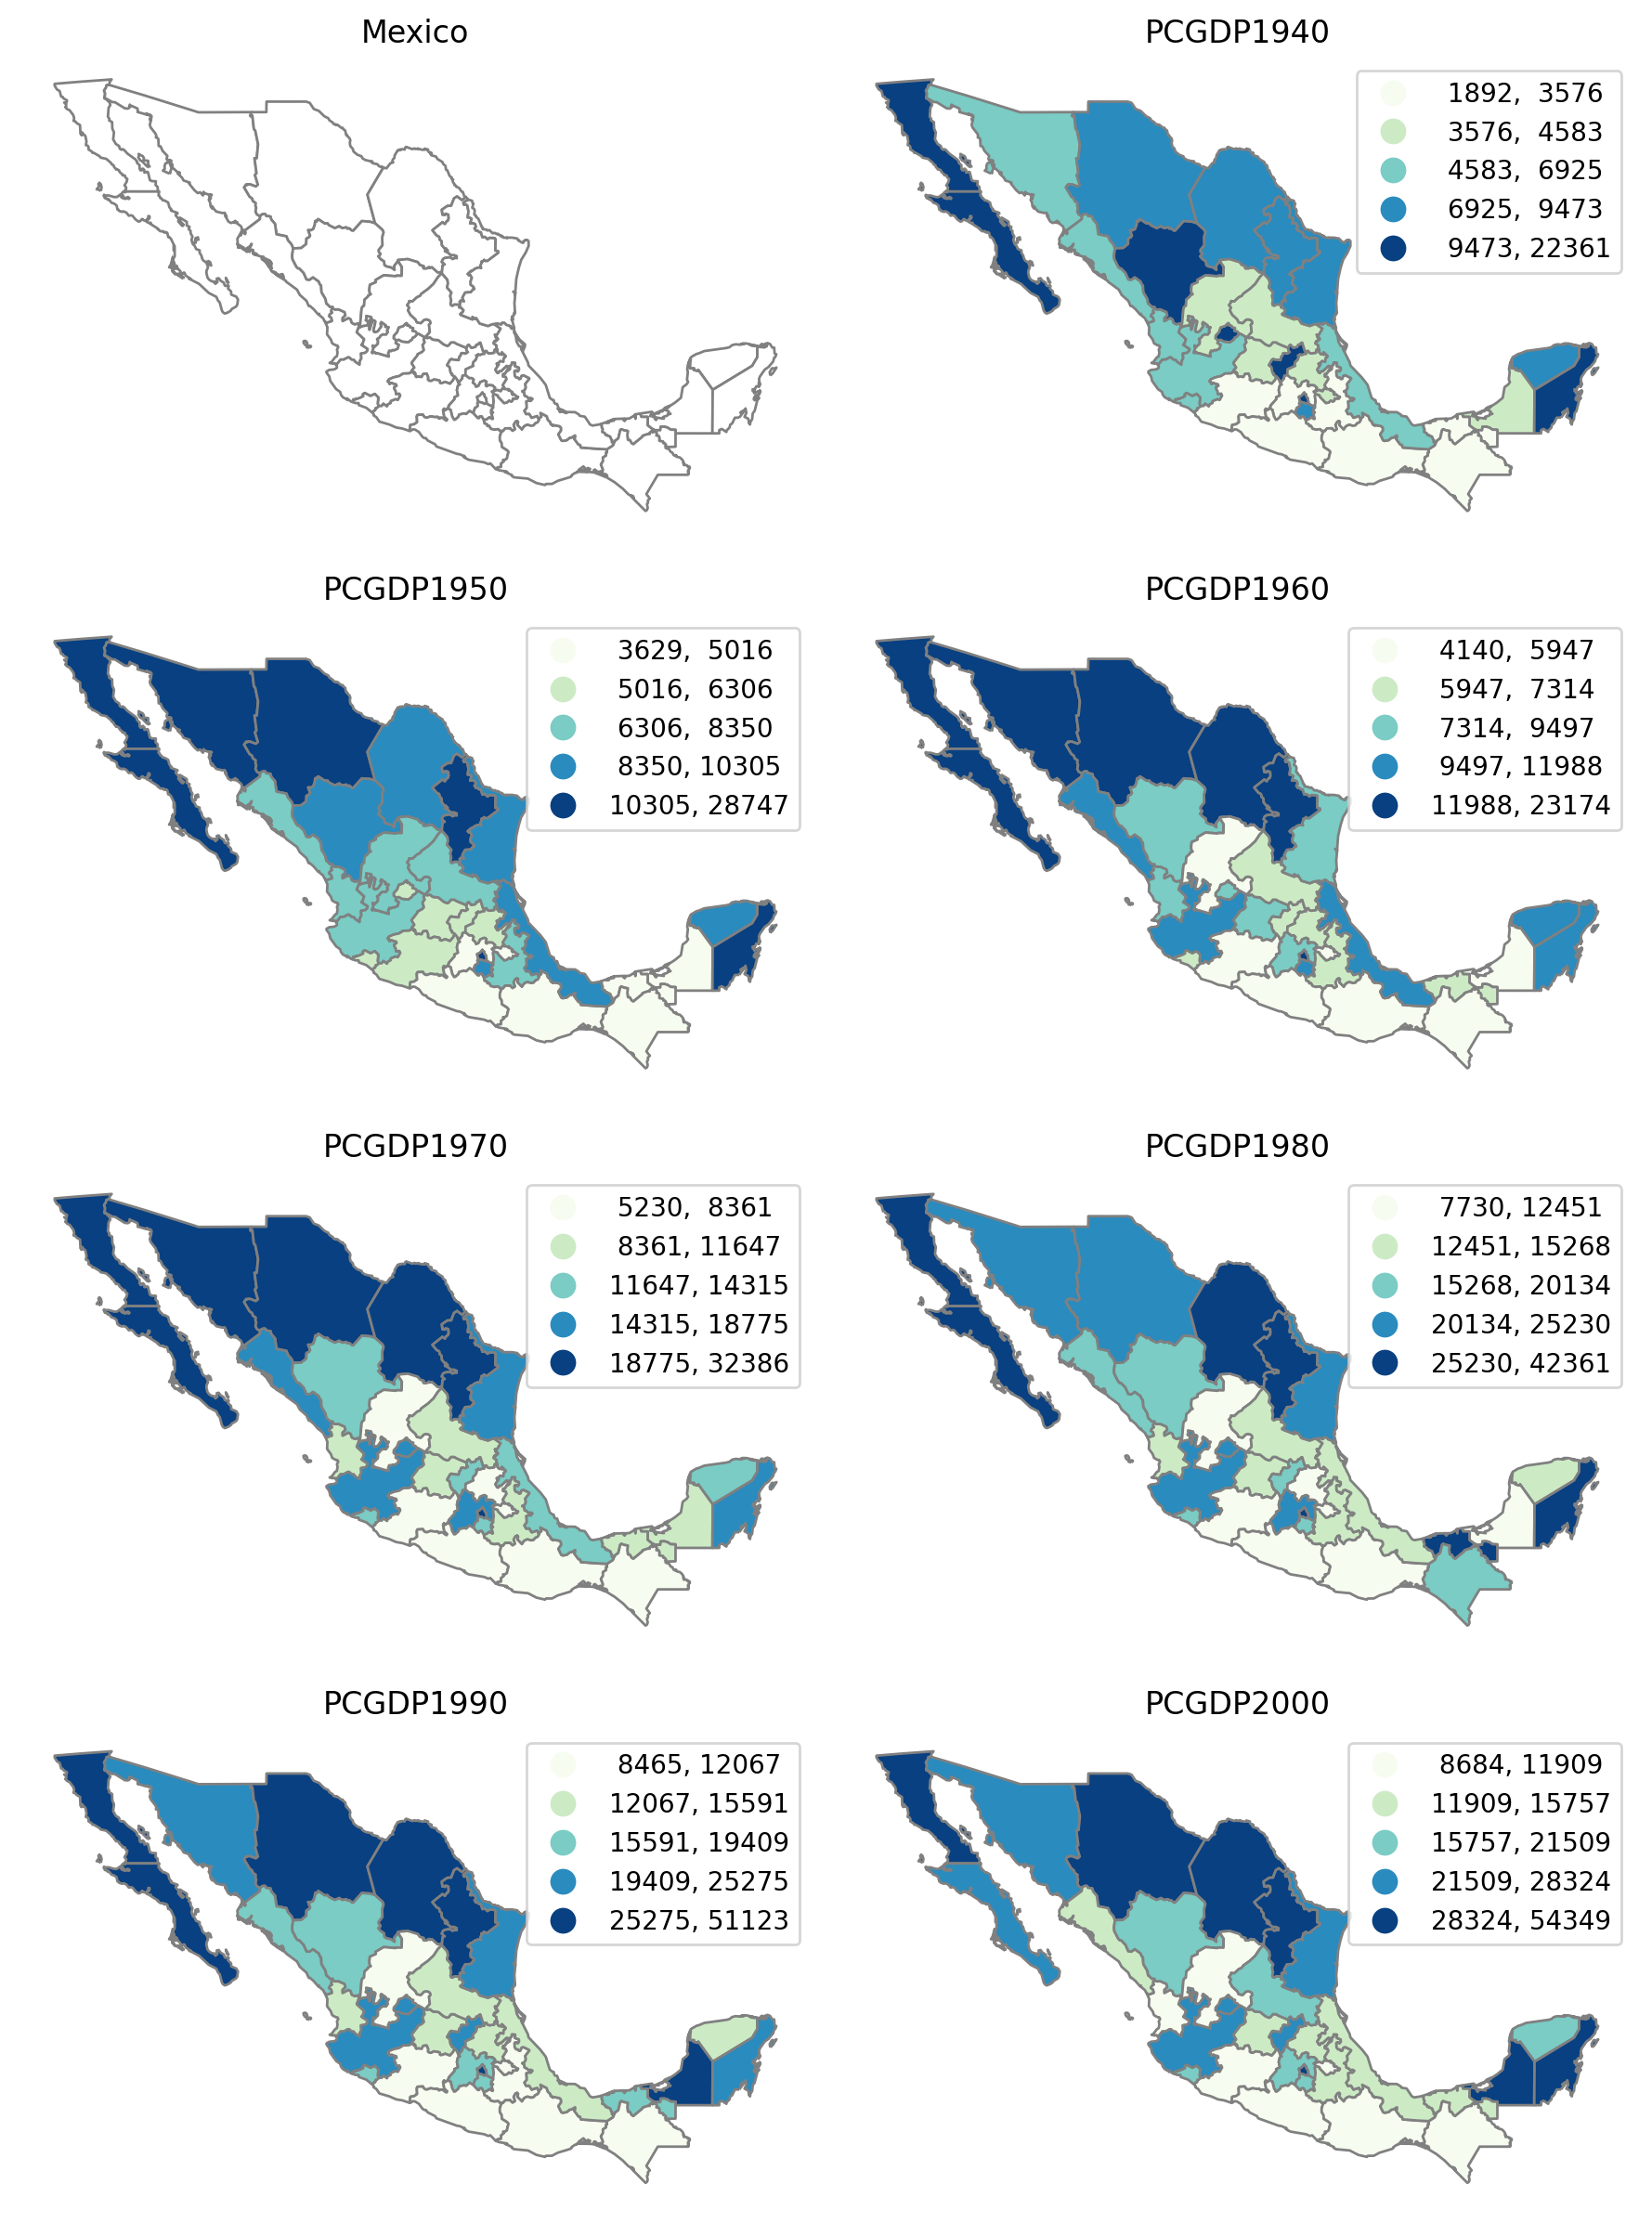

In [6]:
subplotter(mexico, mxgdp_years_grid, None)

In general terms, the north-south divide in incomes is present in each of the 7 decades. There is some variation in states moving across quintiles however, and this is true at both the bottom and top of the state income distribution.

To develop a holistic view of the Mexican space economy over this timespan, we can try to form a set of spatially connected regions that maximizes the internal socieconomic levels of the states belonging to each region.

## Pooled Regionalization

To develop our holistic view, we can treat the six cross-sections as a multidimensional array and seek to 
cluster 32 Mexican states into the maximum number of regions such that each region as at least 6 = 32 // 5 states and homogeneity in per capita gross regional product over 1940-2000 is maximized.

We first define the variables in the dataframe that will be used to measure regional homogeneity:

In [7]:
attrs_name = [f"PCGDP{year}" for year in mxgdp_years[1:]]
attrs_name

['PCGDP1940',
 'PCGDP1950',
 'PCGDP1960',
 'PCGDP1970',
 'PCGDP1980',
 'PCGDP1990',
 'PCGDP2000']

Next, we specify a number of parameters that will serve as input to the `max-p` model.

A [spatial weights object](https://pysal.org/libpysal/tutorial.html) expresses the spatial connectivity of the states:

In [8]:
with warnings.catch_warnings(record=True):
    w = libpysal.weights.Queen.from_dataframe(mexico)

The remaining arguments are the minimum number of states each region must have (`threshold`):

In [9]:
threshold = 6

and the number of the top candidate regions to consider when assigning enclaves (`top_n`):

In [10]:
top_n = 2

We create the attribute `count` which will serve as the threshold attribute which we add to the dataframe:

In [11]:
mexico["count"] = 1
threshold_name = "count"

The model can then be instantiated and solved:

In [12]:
numpy.random.seed(RANDOM_SEED)
model = MaxP(mexico, w, attrs_name, threshold_name, threshold, top_n)
model.solve()

In [13]:
mexico["maxp_new"] = model.labels_

In [14]:
mexico[["maxp_new", "AREA"]].groupby(by="maxp_new").count()

,AREA
maxp_new,
1,6
2,7
3,6
4,7
5,6


In [15]:
model.p

5

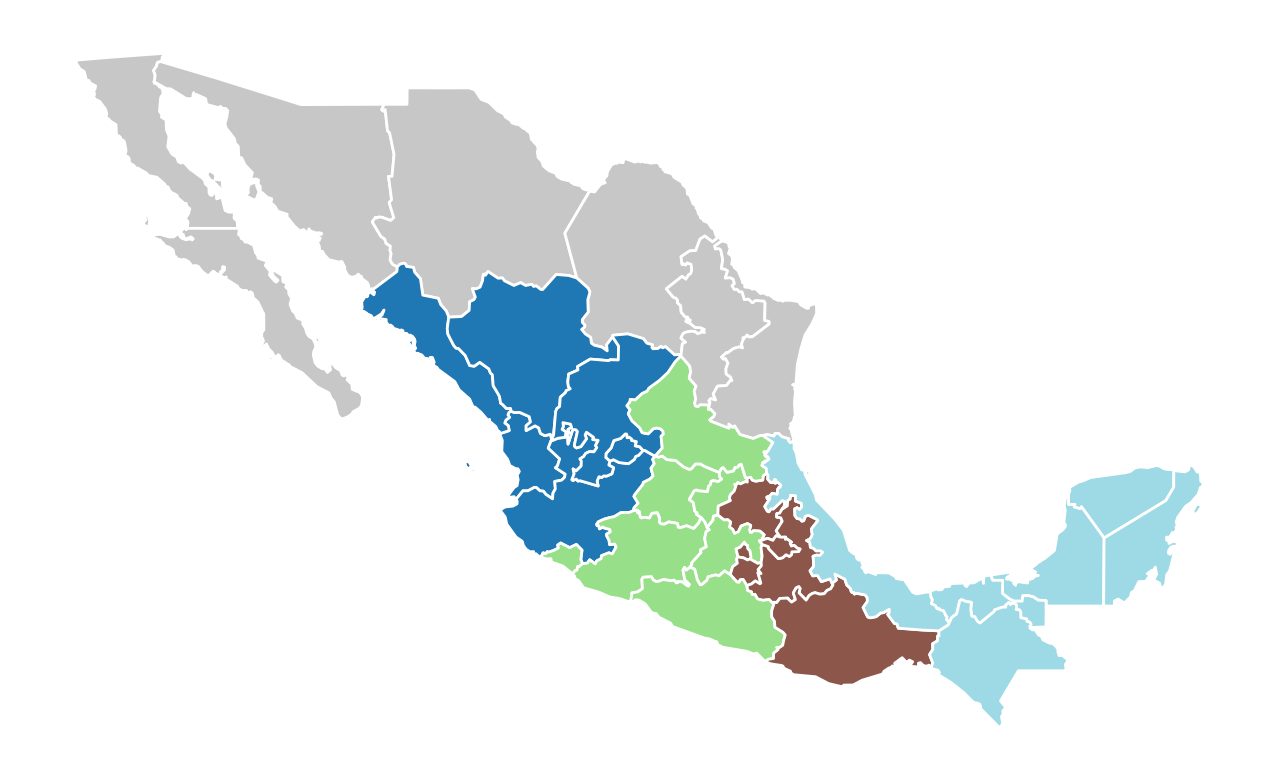

In [16]:
mexico.plot(figsize=(8, 5), column="maxp_new", cmap="tab20", edgecolor="w").axis("off");

The model solution results in five regions, three of which have six states, and two with seven states each. Each region is a [spatially connected component](https://en.wikipedia.org/wiki/Connected_space), as required by the `max-p` problem.

## Change threshold to a minimum of 3 states per region

In [17]:
numpy.random.seed(RANDOM_SEED)
threshold = 3
model = MaxP(mexico, w, attrs_name, threshold_name, threshold, top_n)
model.solve()

In [18]:
mexico["maxp_3"] = model.labels_
mexico[["maxp_3", "AREA"]].groupby(by="maxp_3").count()

,AREA
maxp_3,
1,3
2,3
3,4
4,3
5,3
6,3
7,4
8,3
9,3


In [19]:
model.p

10

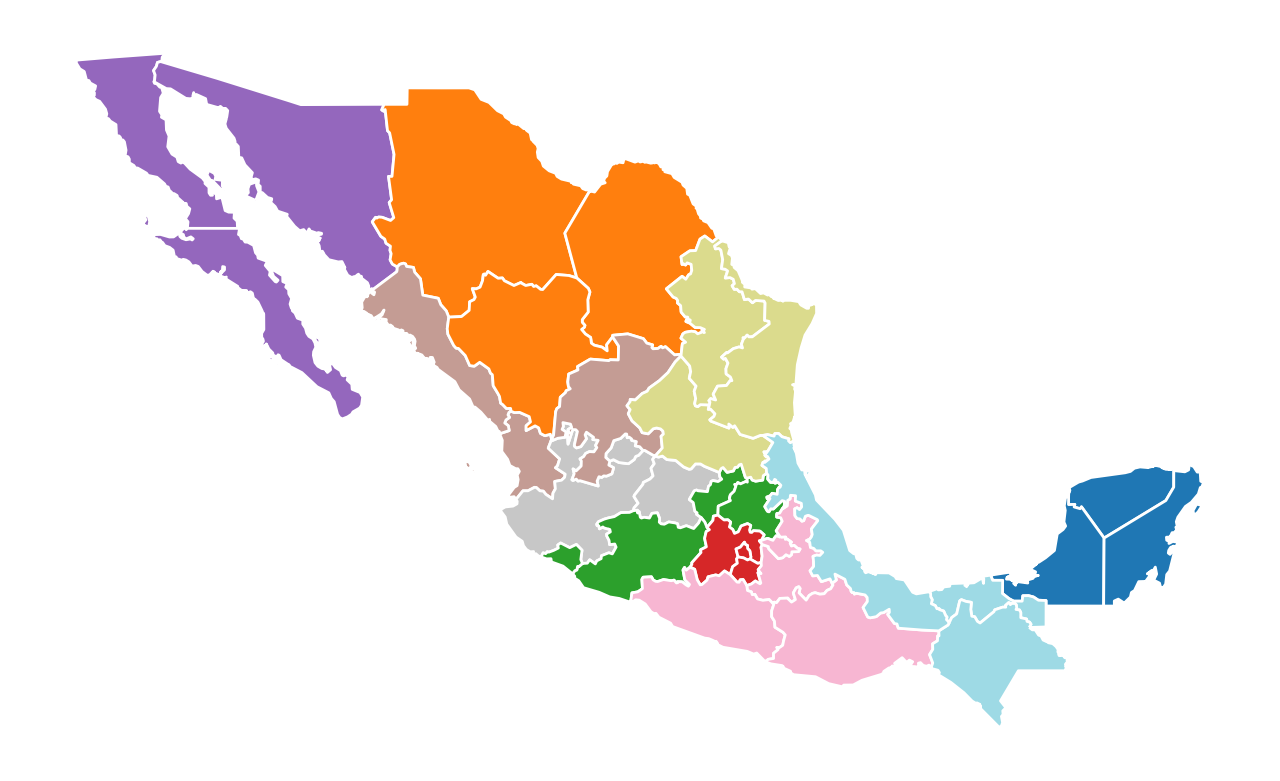

In [20]:
mexico.plot(figsize=(8, 5), column="maxp_3", cmap="tab20", edgecolor="w").axis("off");

## Year-by-Year Regionalization while Varying Parameters

### Vary minimum in-region threshold (5, 10, 15); hold enclave assignment constant (2)

**5 states**

In [21]:
region_args = mexico, mxgdp_years_grid, w

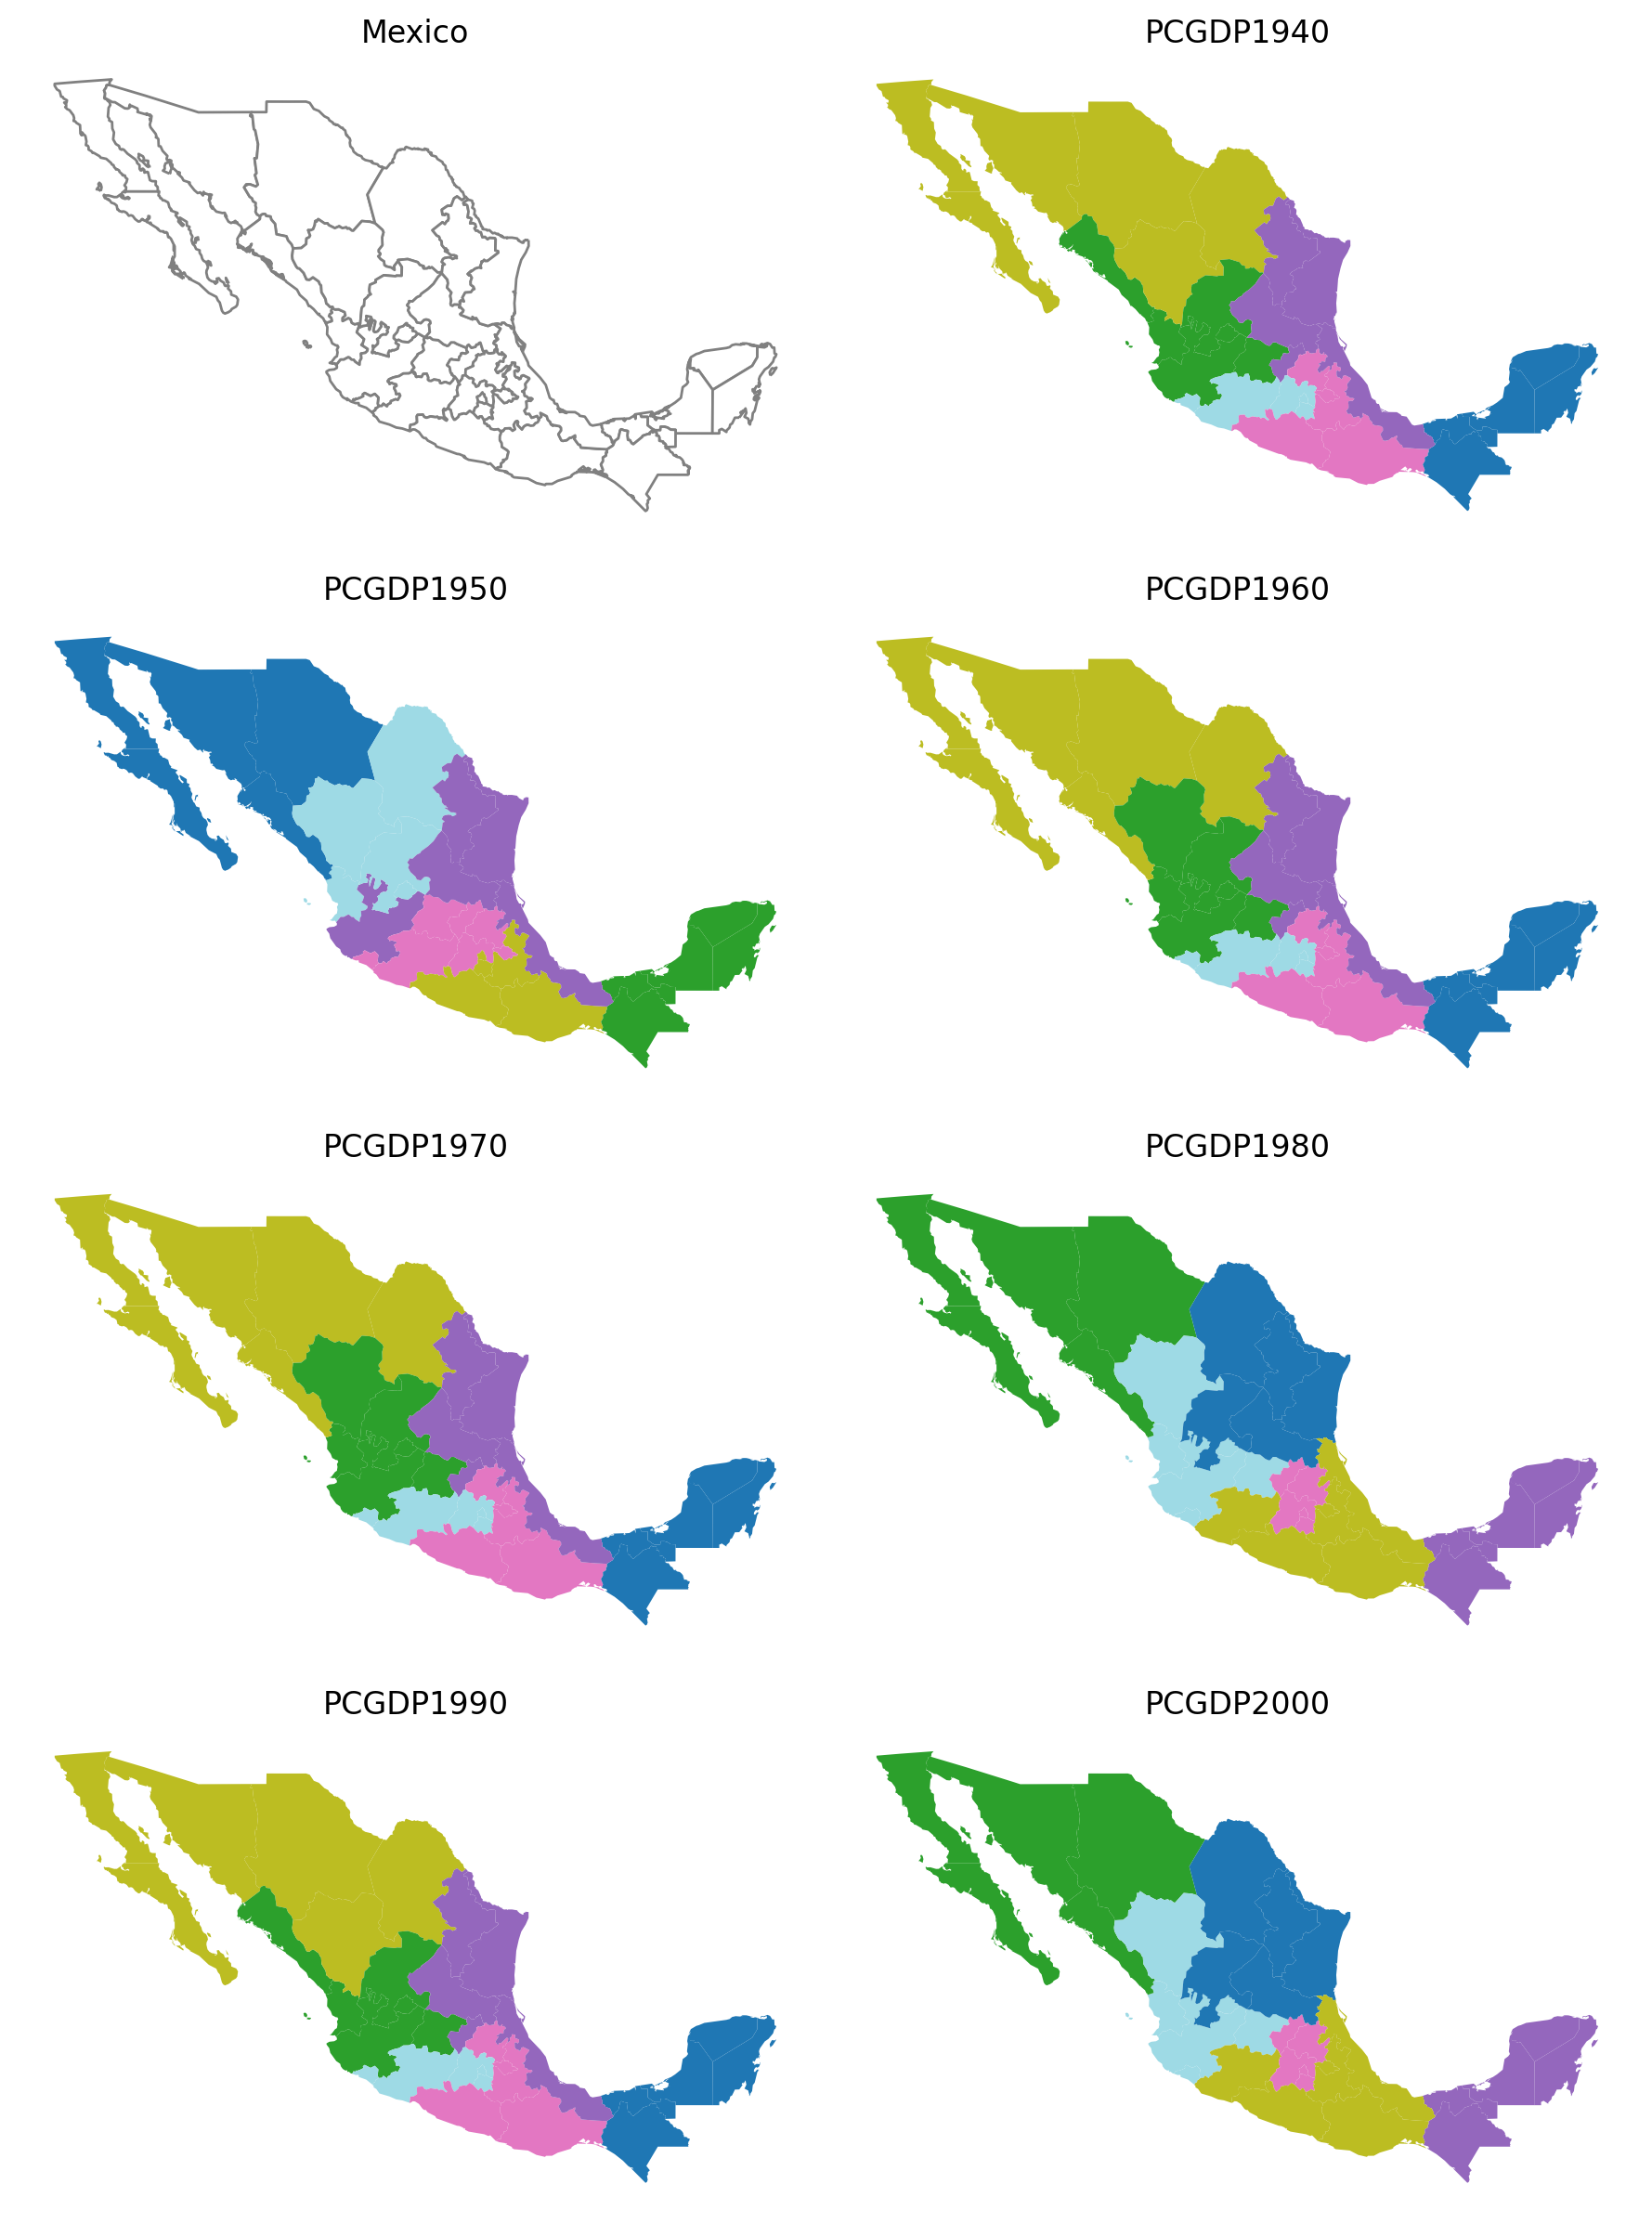

In [22]:
subplotter(*region_args, threshold=5, top_n=2)

**10 states**

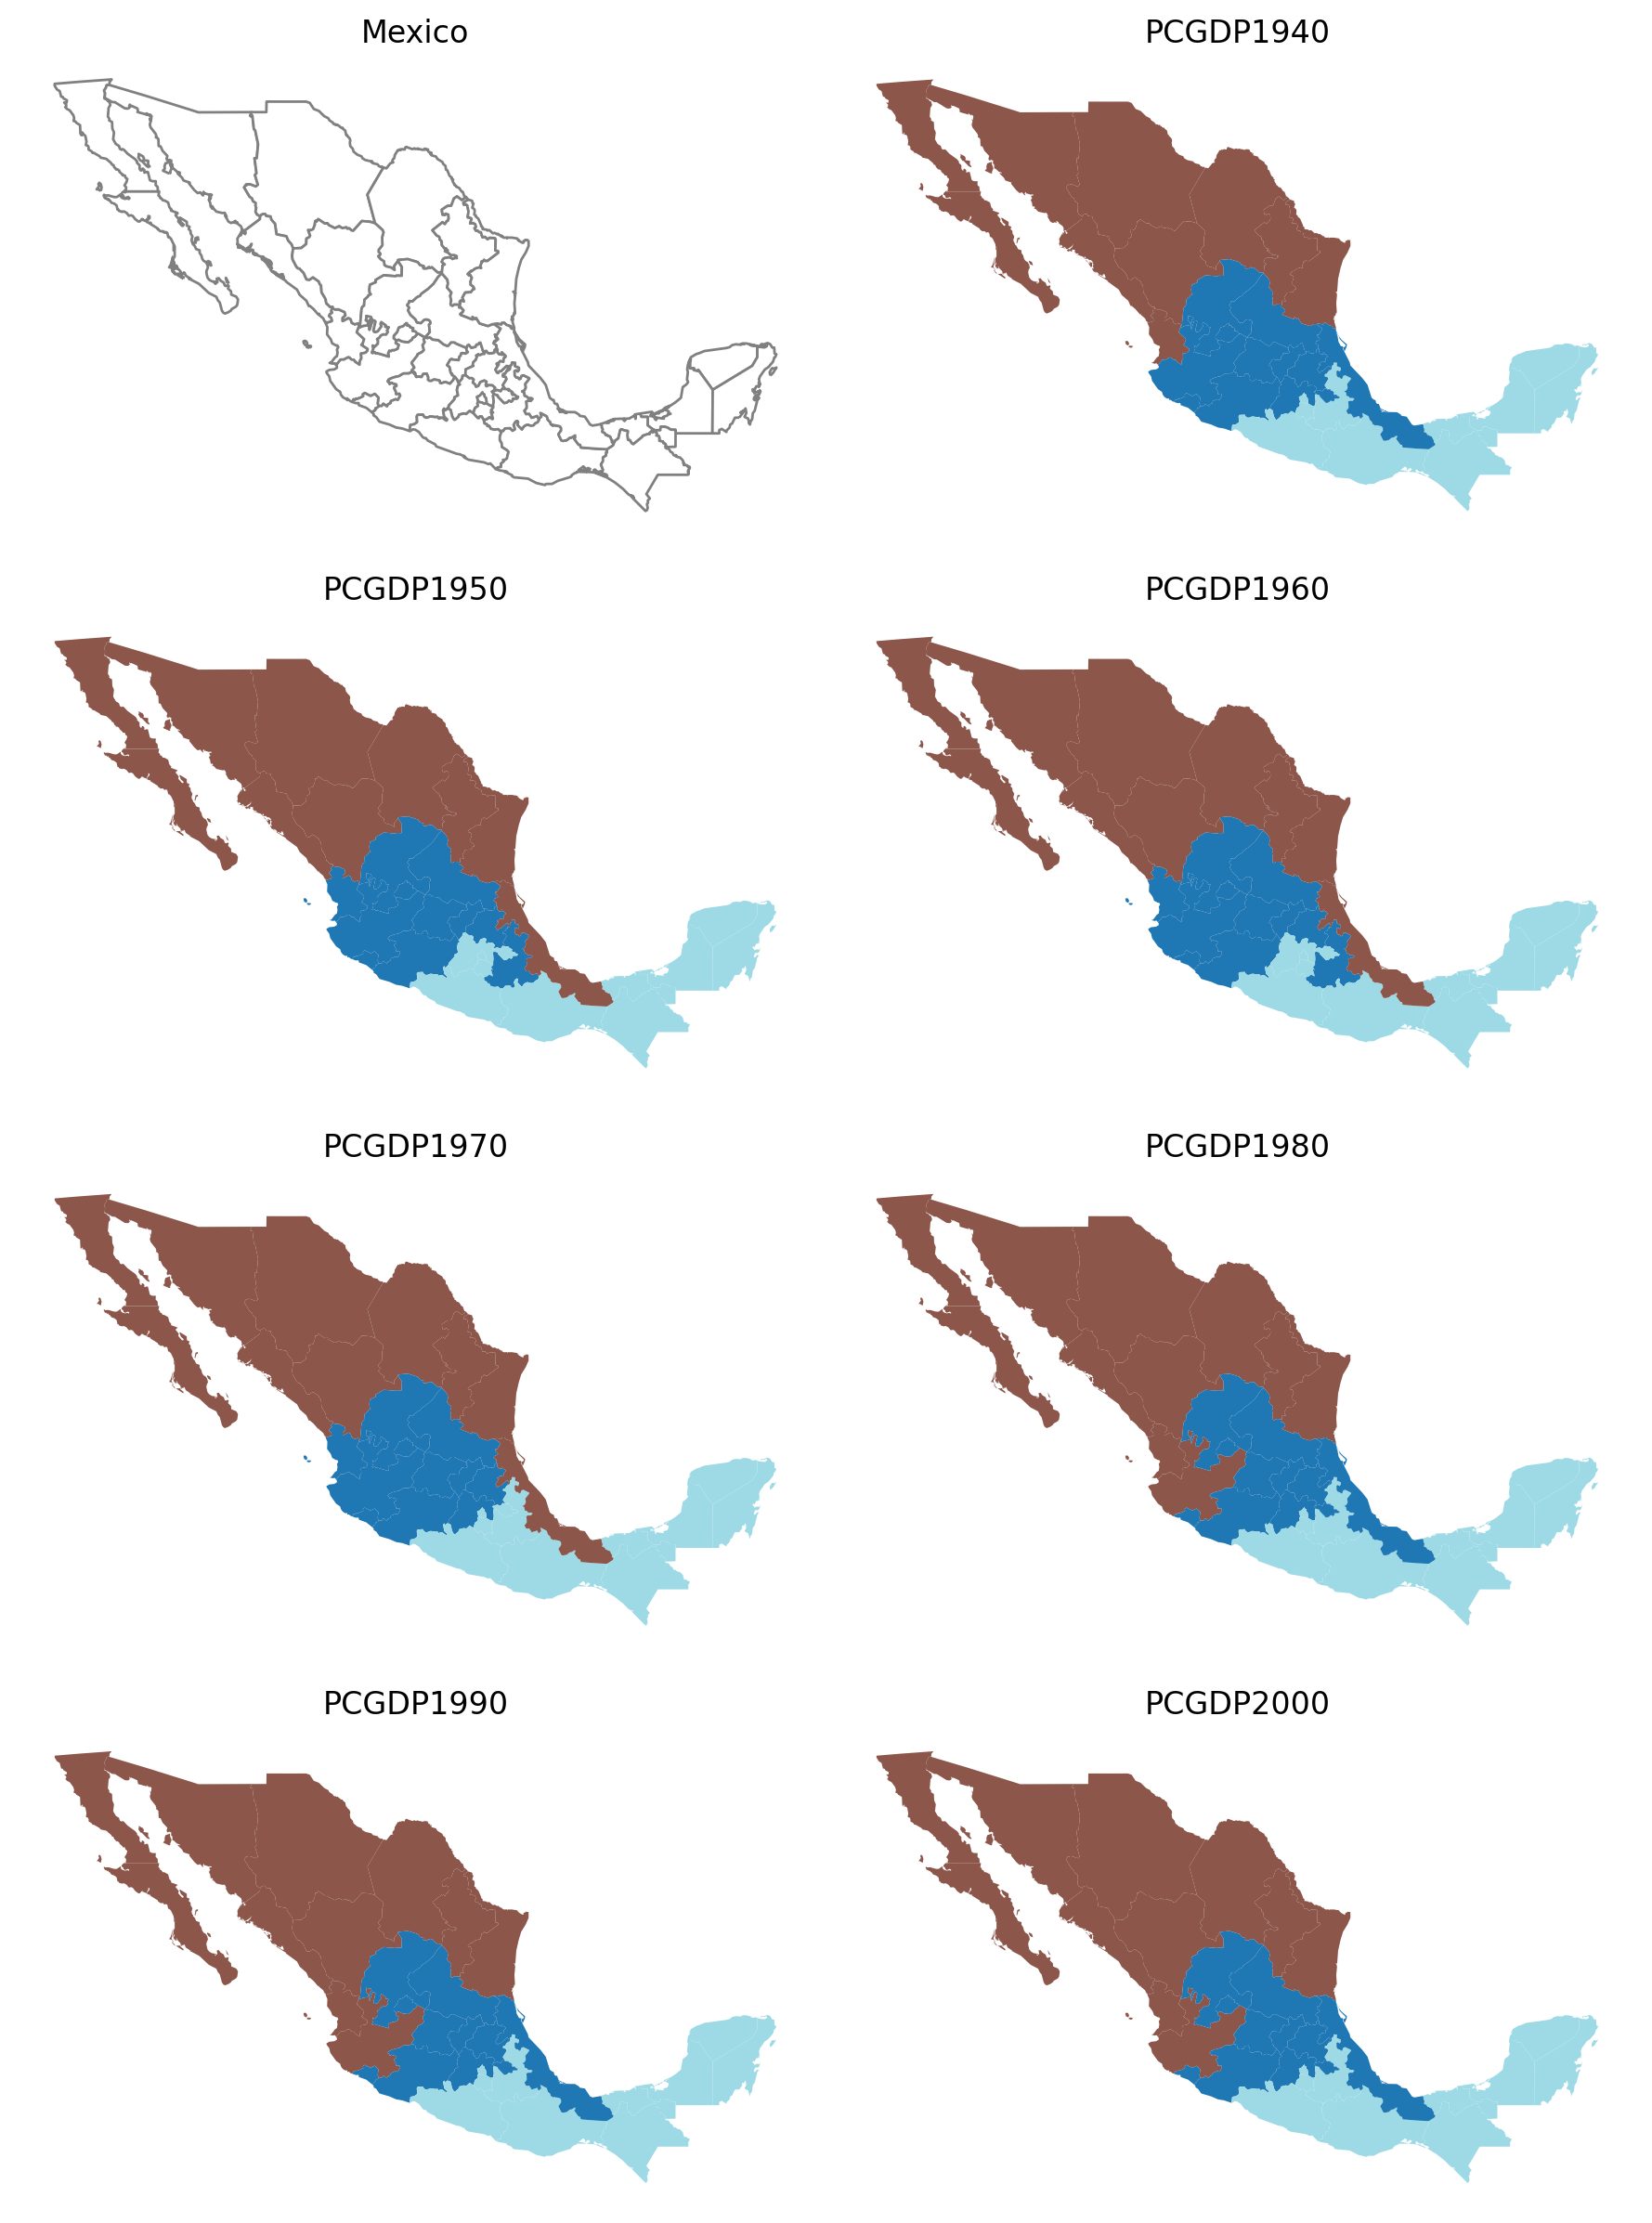

In [23]:
subplotter(*region_args, threshold=10, top_n=2)

**15 states**

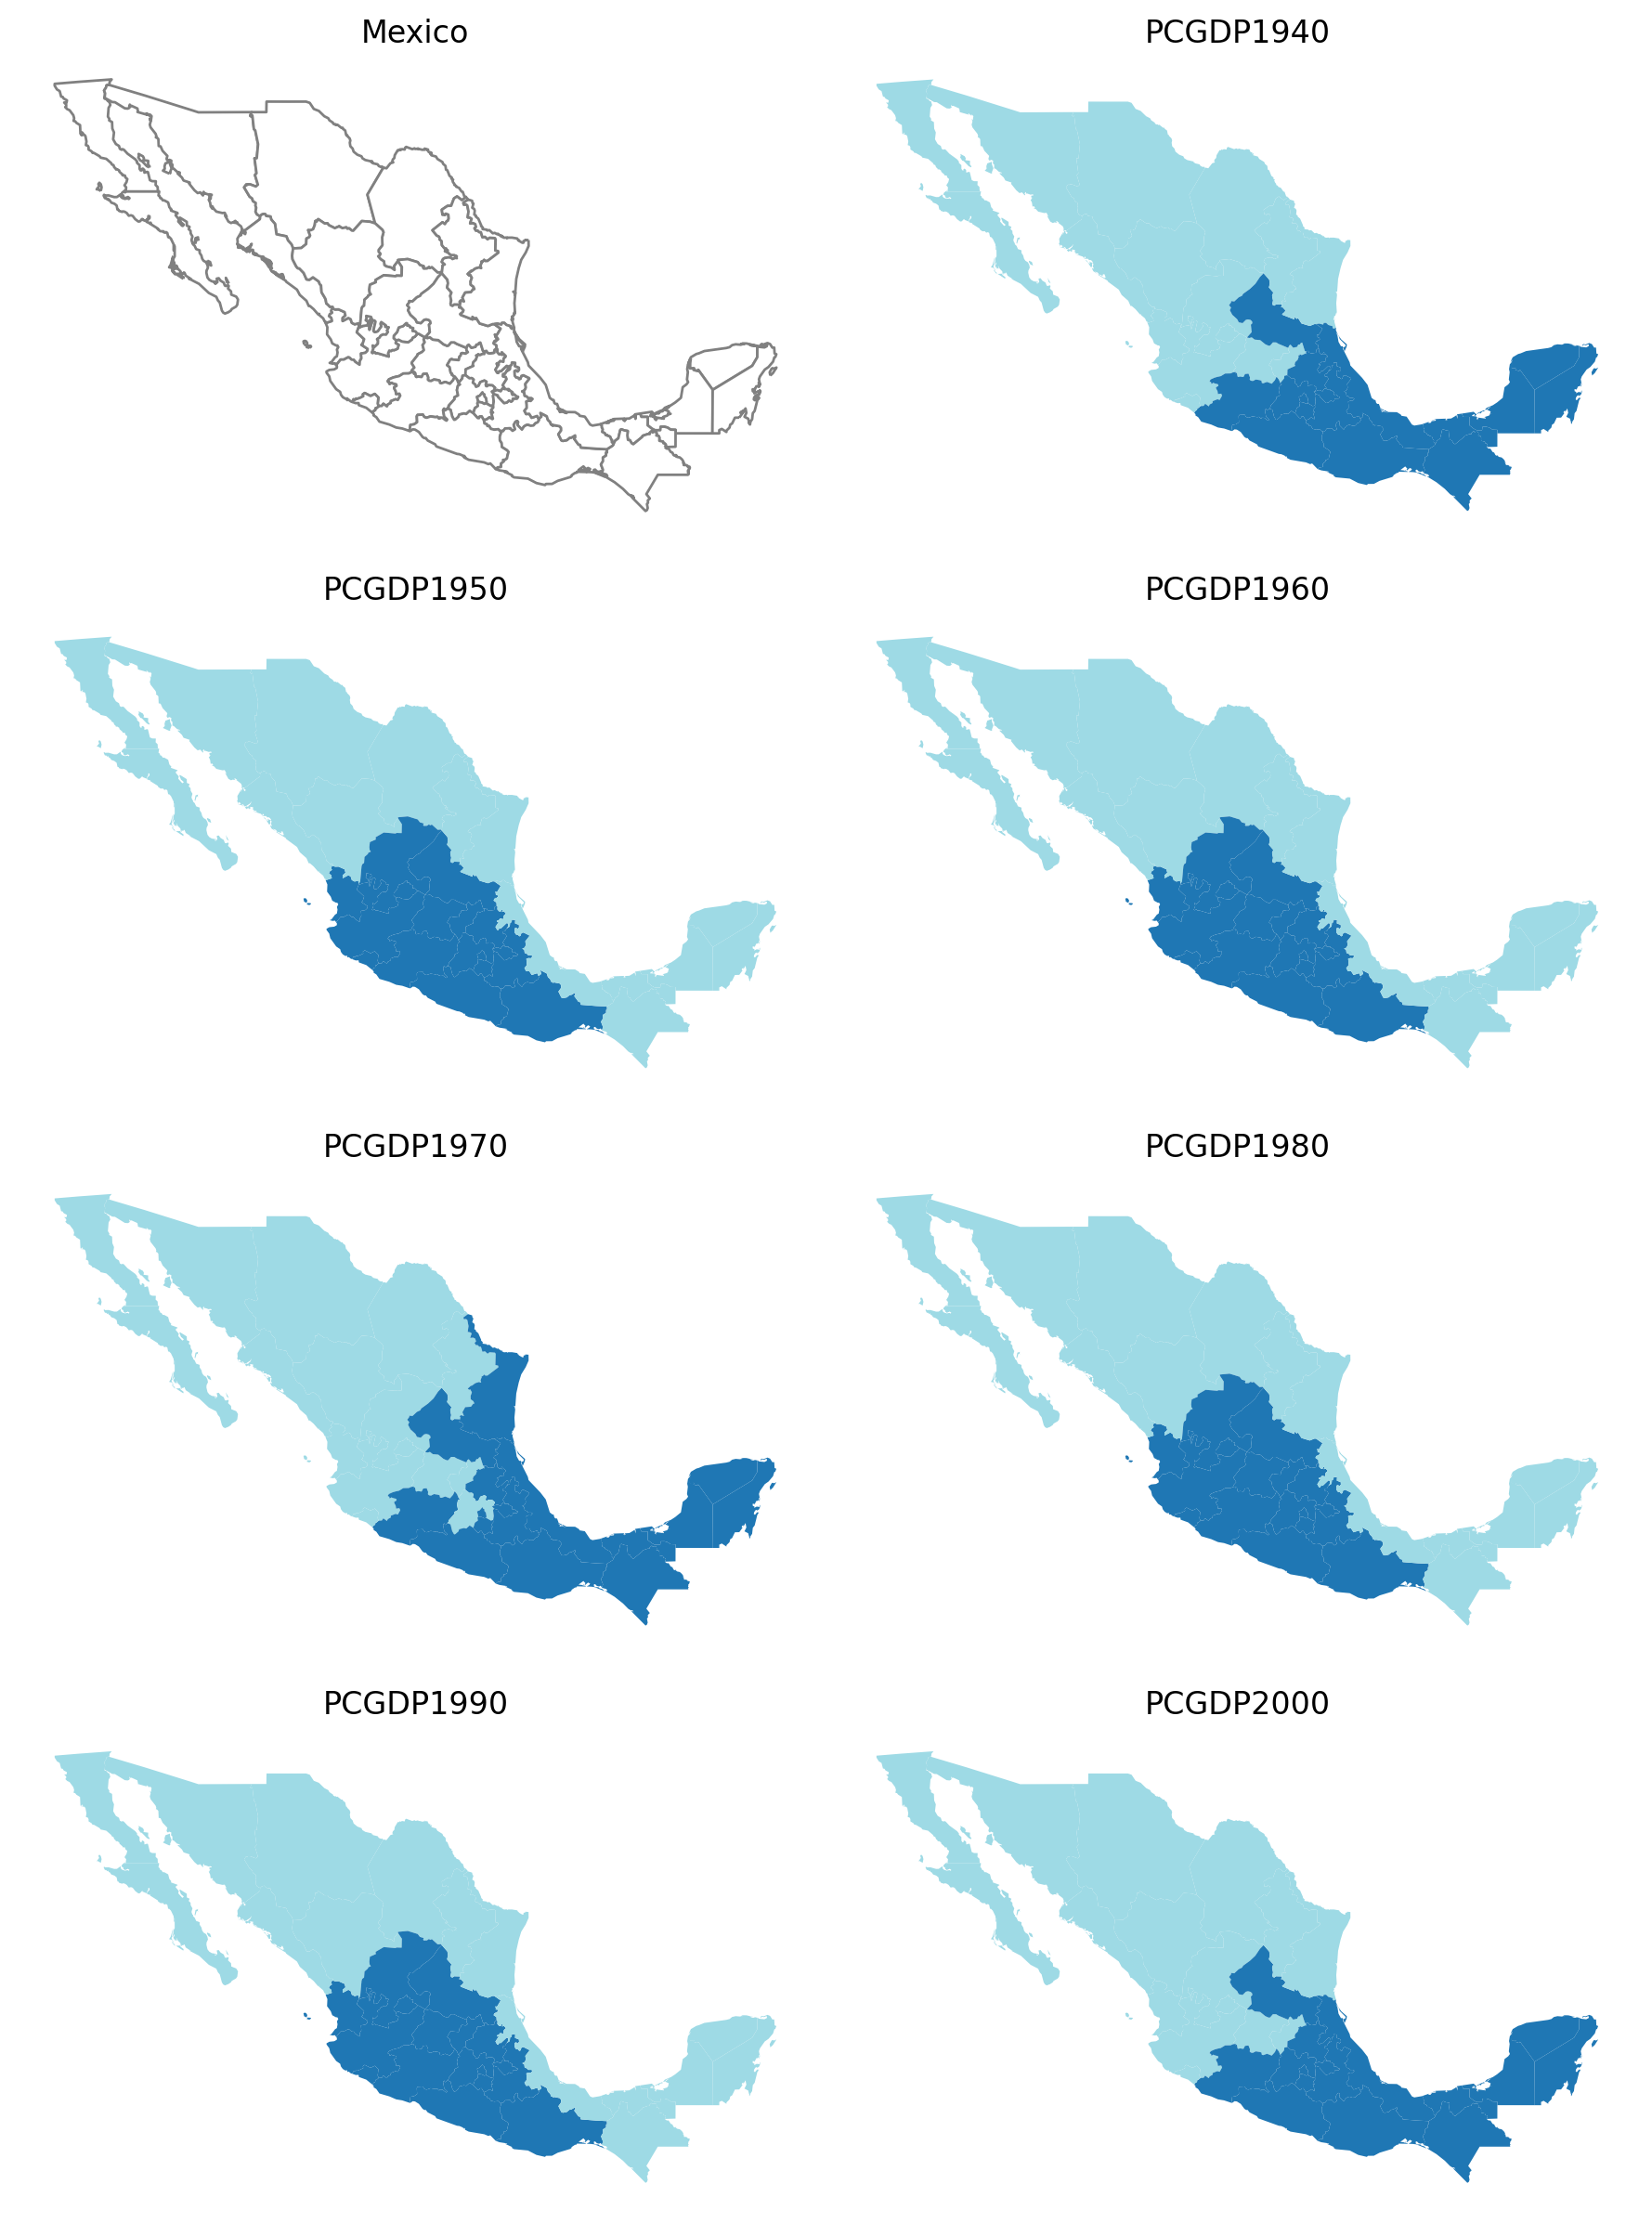

In [24]:
subplotter(*region_args, threshold=15, top_n=2)

###  Vary state enclave assignments (1, 3, 5); hold minimum in-region threshold constant (5)

**1 state**

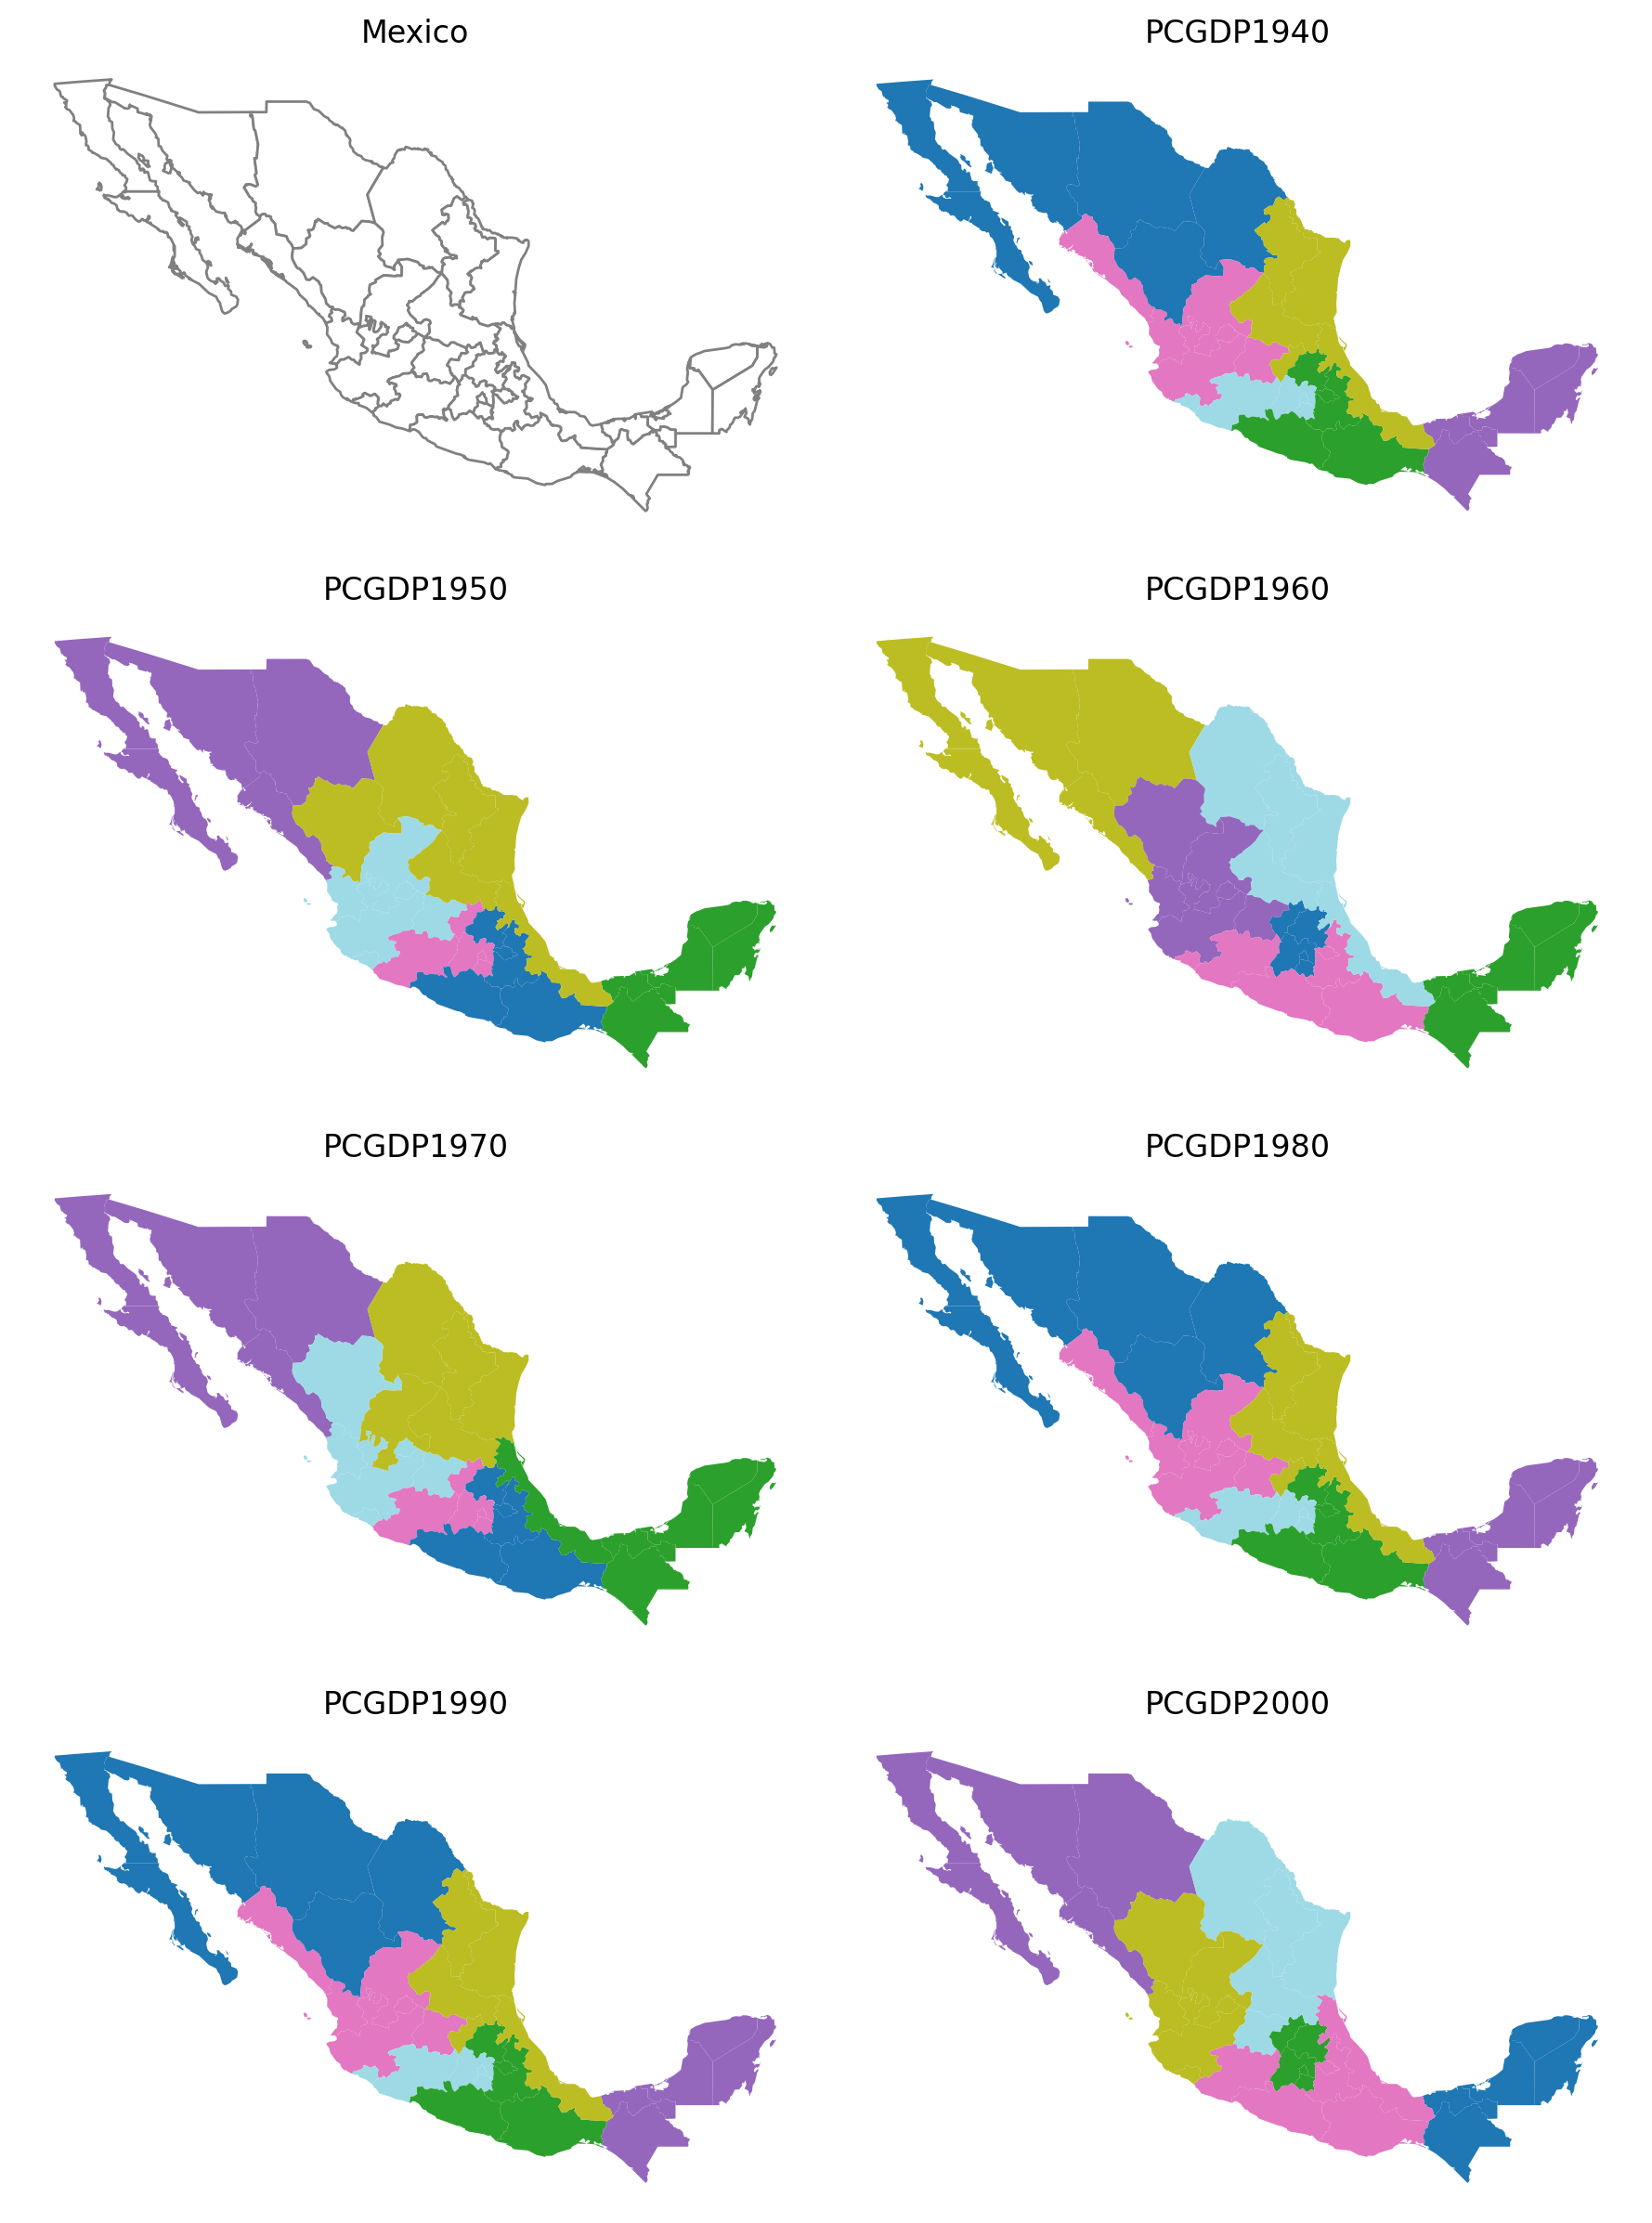

In [25]:
subplotter(*region_args, threshold=5, top_n=1)

**3 states**

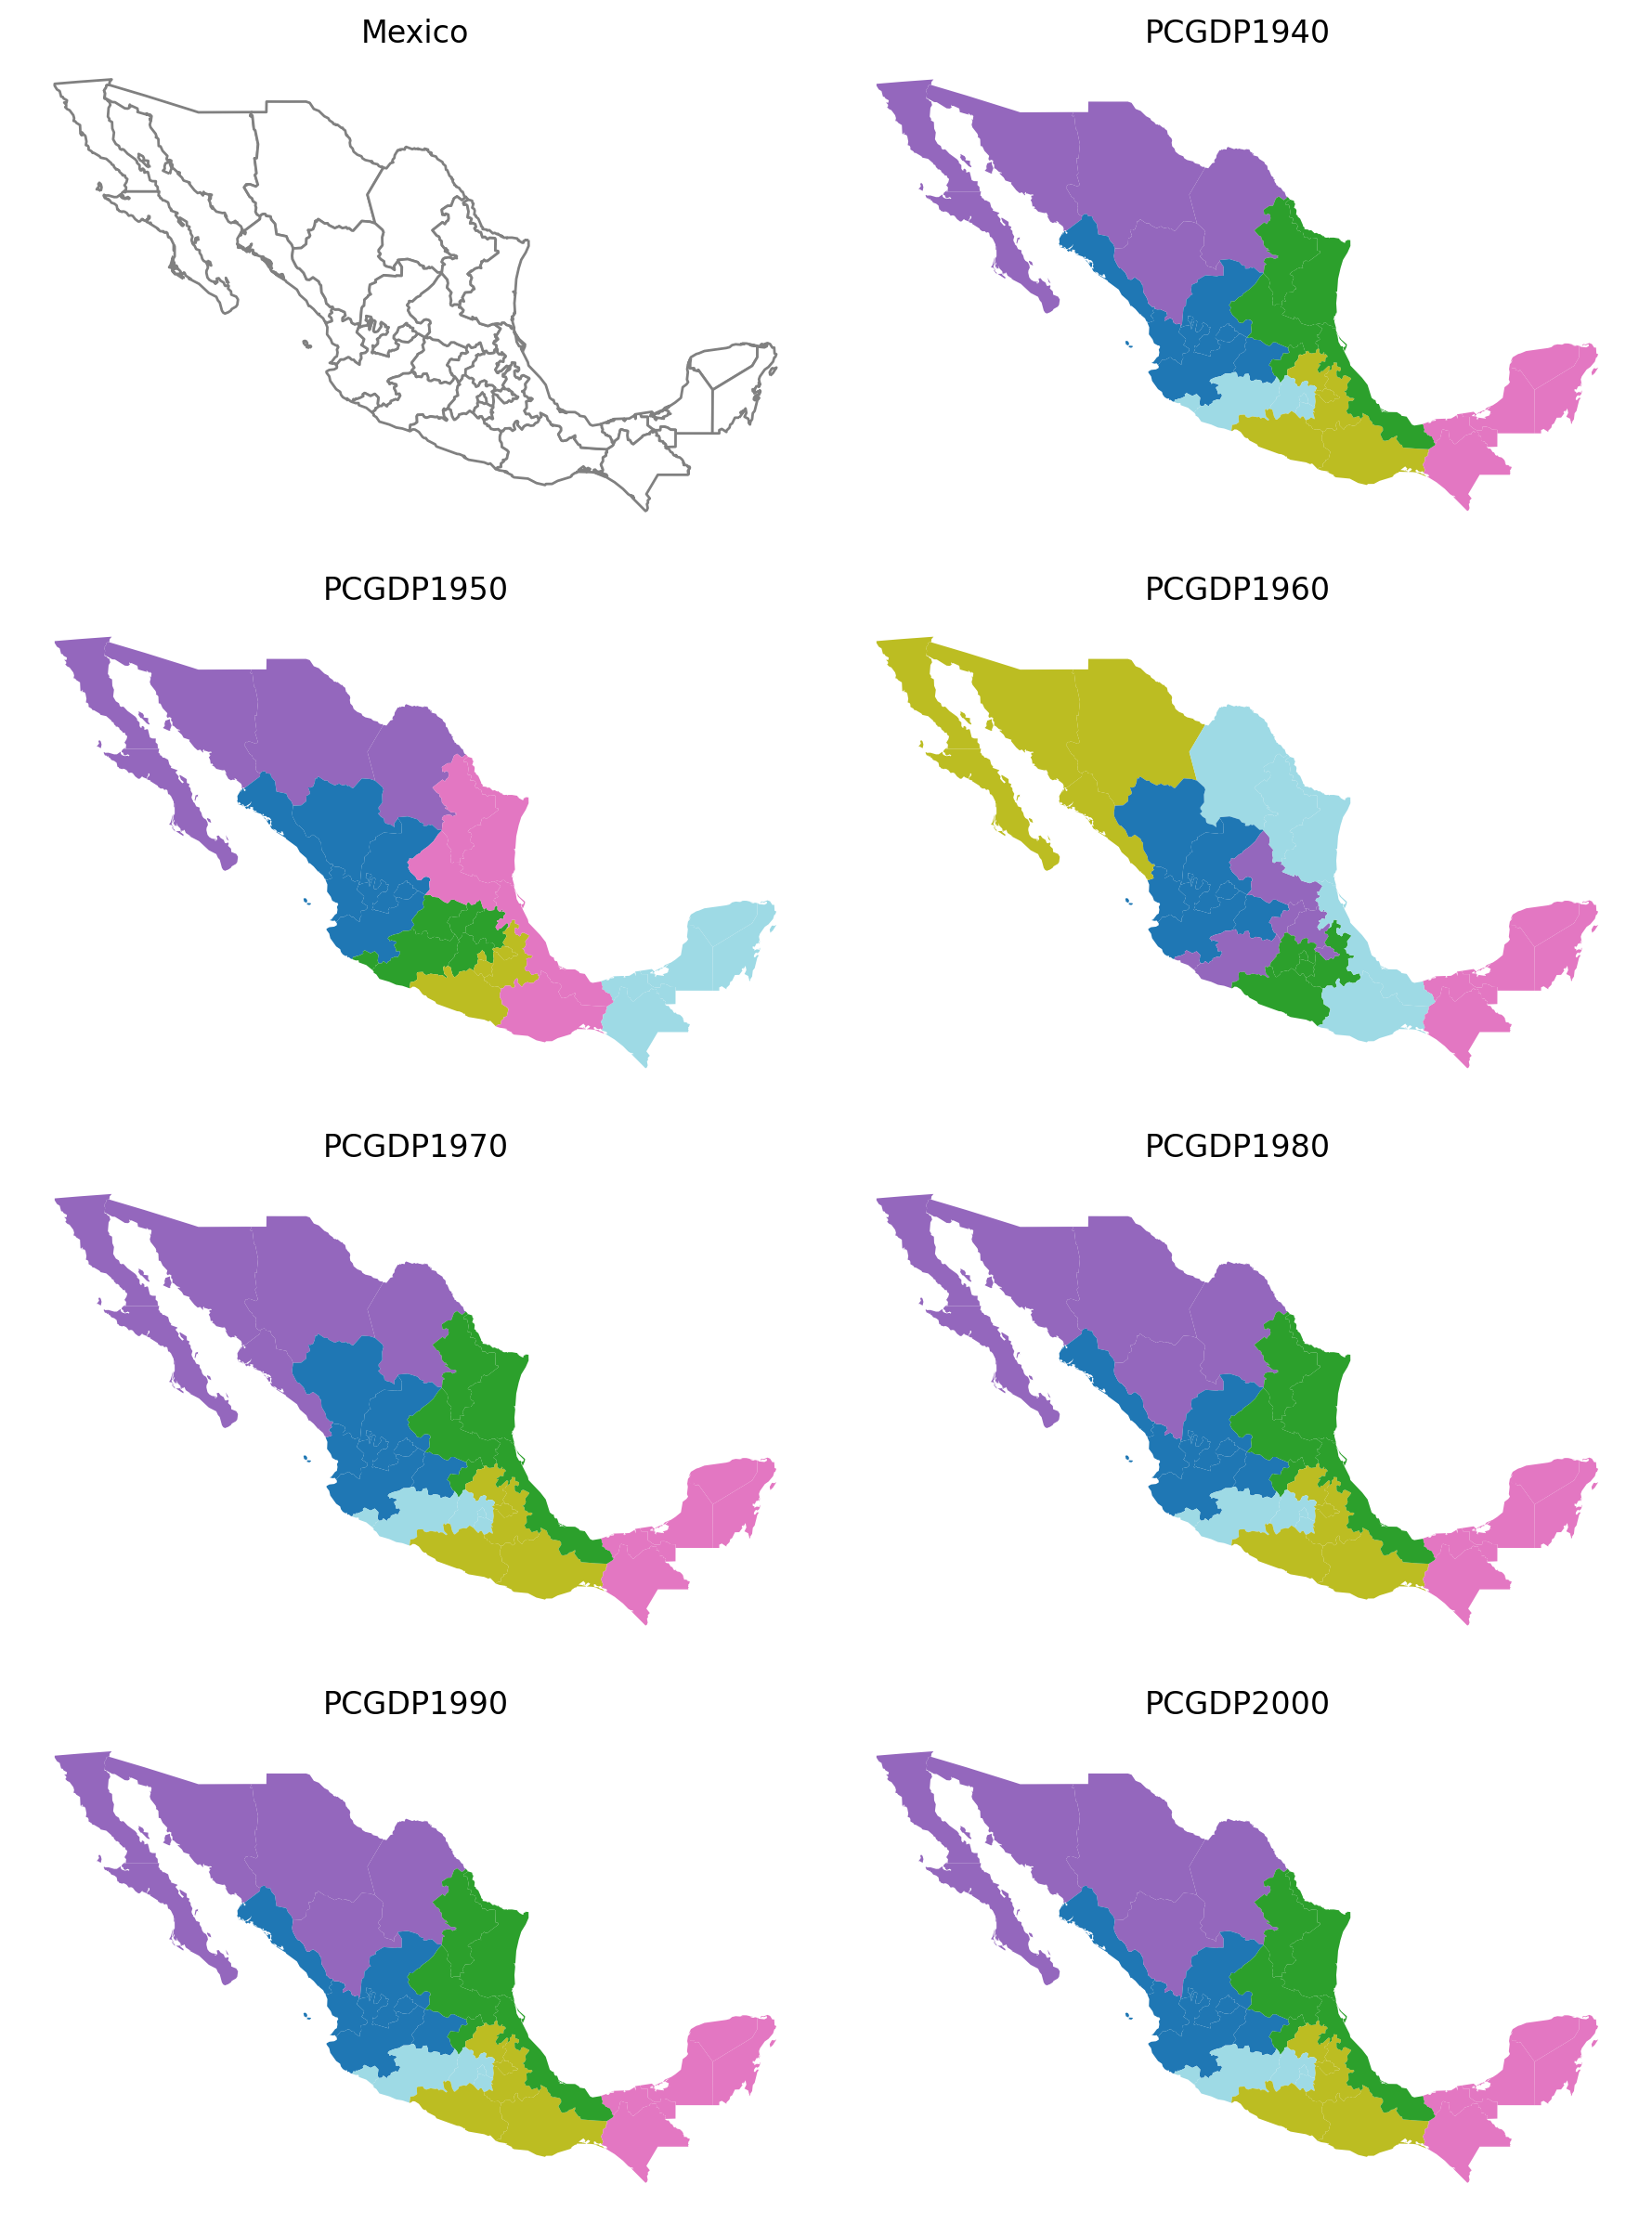

In [26]:
subplotter(*region_args, threshold=5, top_n=3)

**5 states**

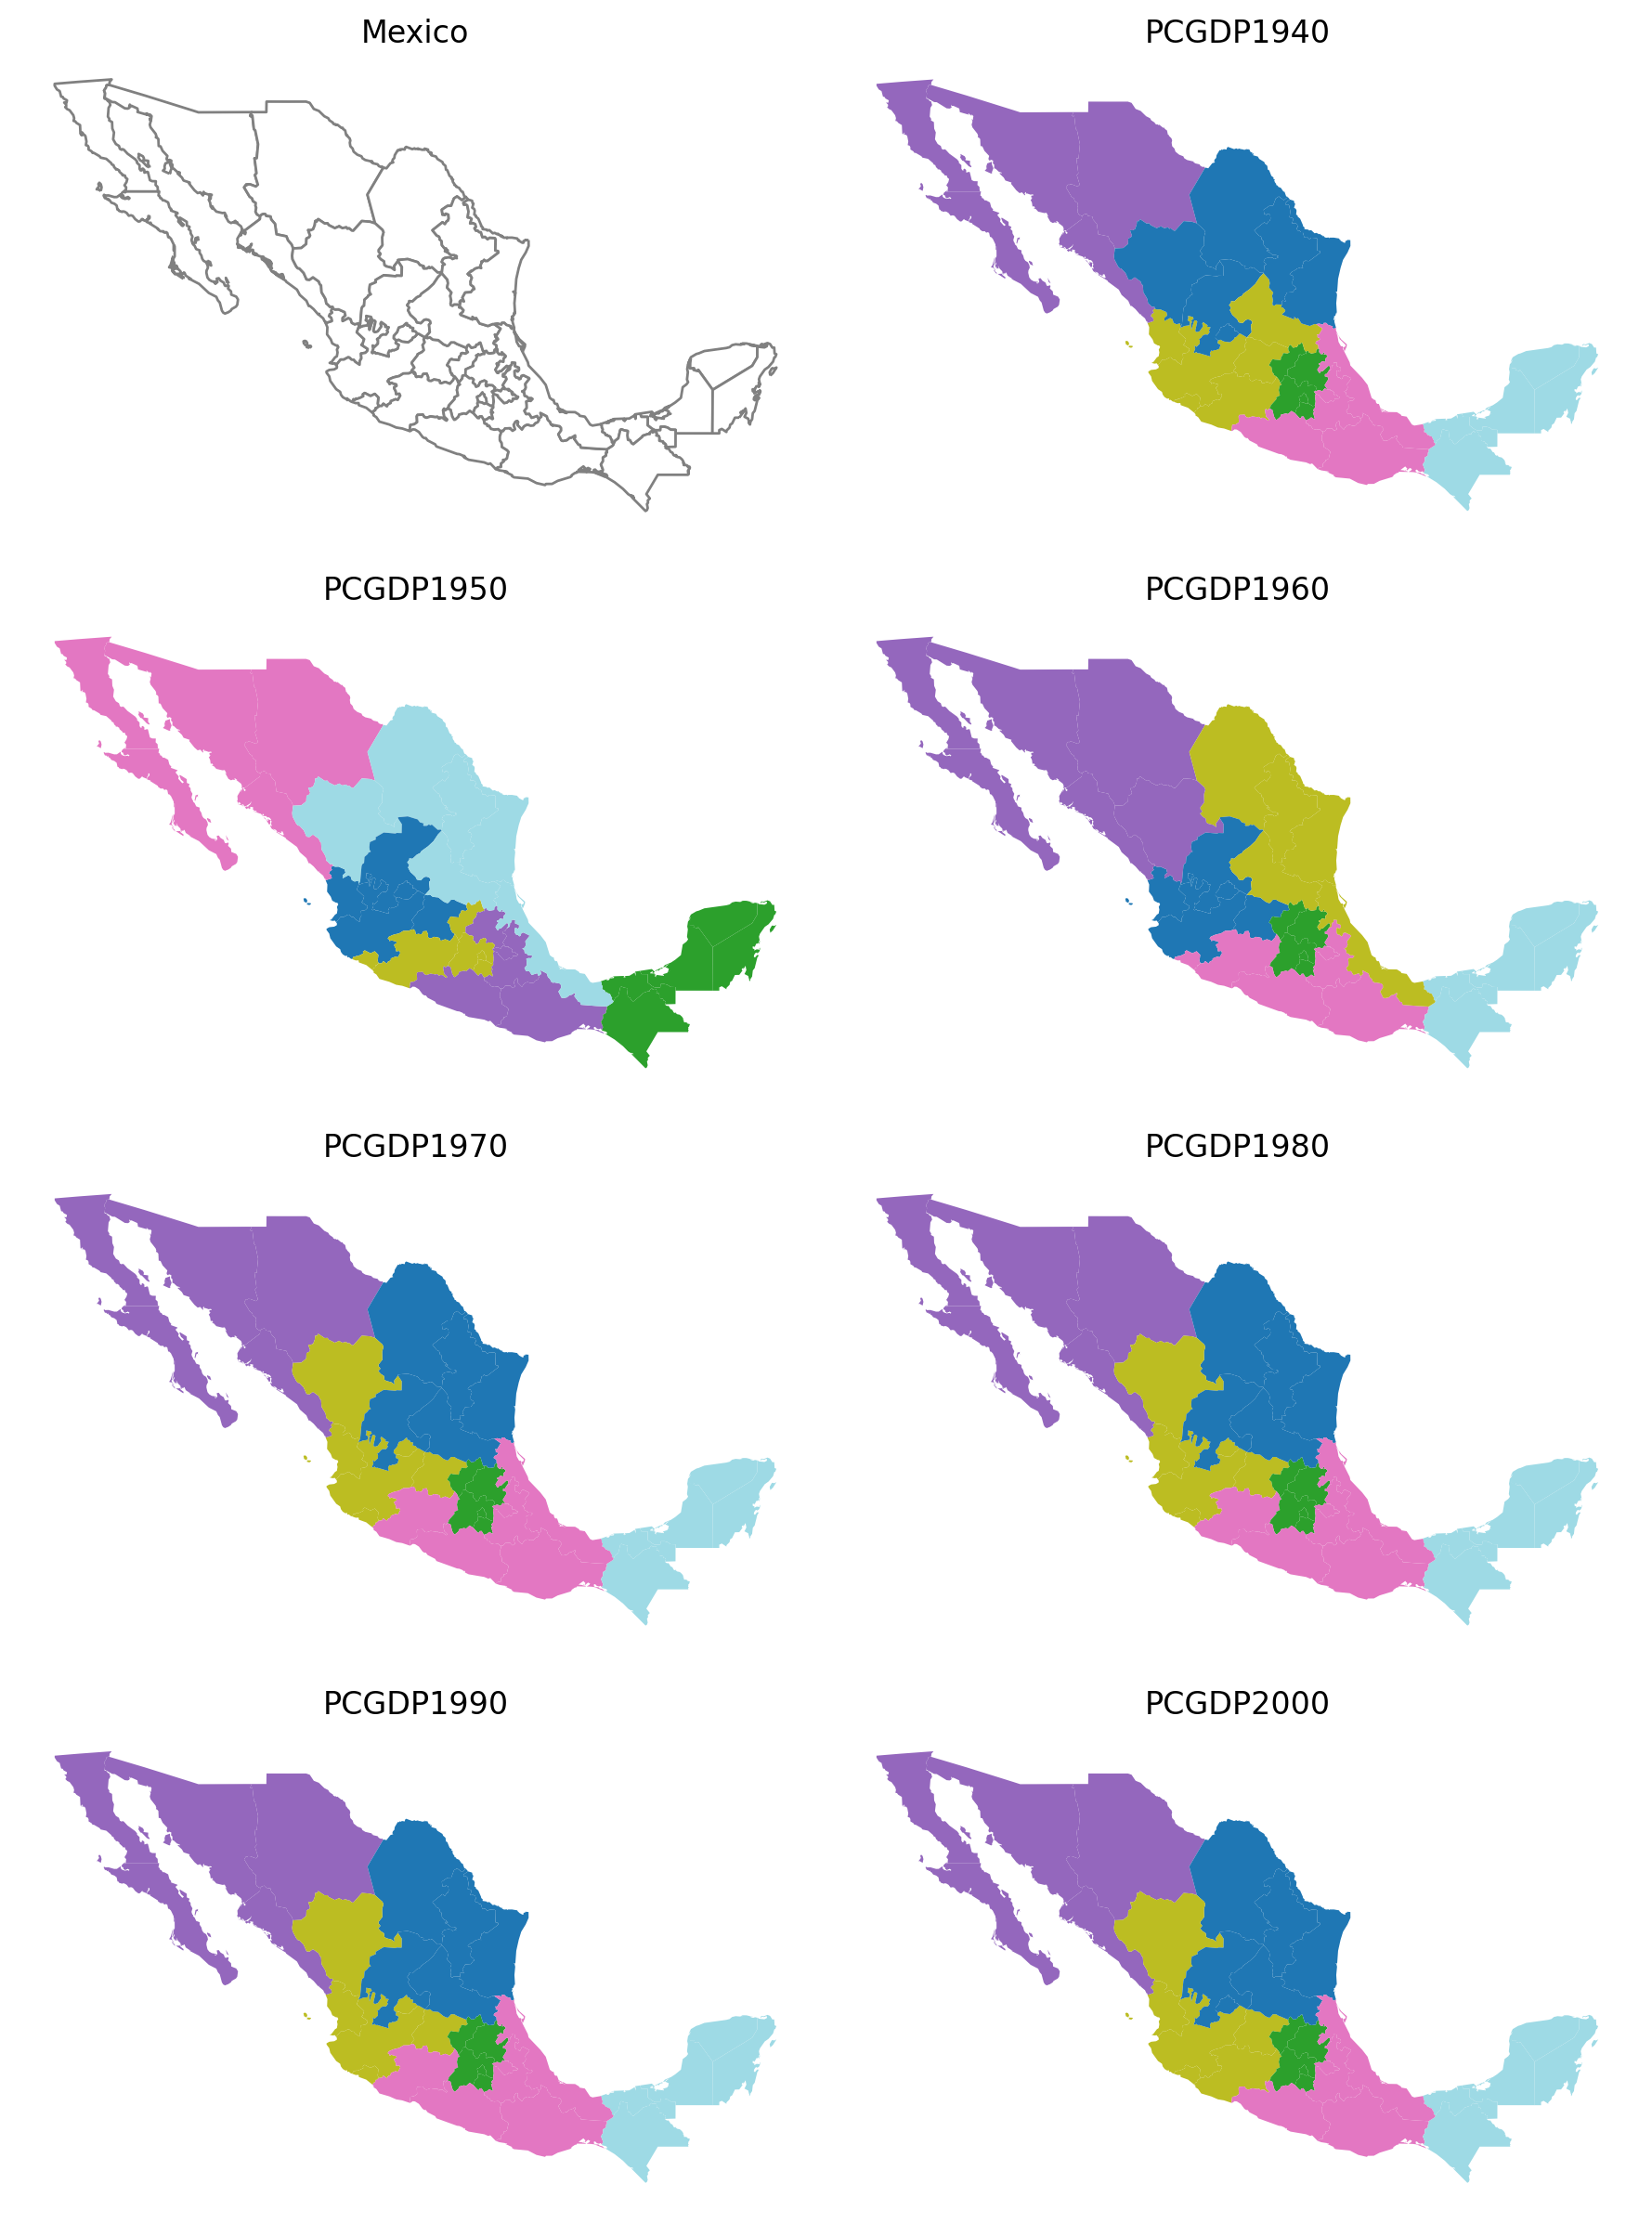

In [27]:
subplotter(*region_args, threshold=5, top_n=5)

As shown here, varying the `threshold` and `top_n` parameters both have a demonstrable effect regionalization outcomes.

-------------------